In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np

print("=== Блок 1: Загрузка и подготовка данных ===")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

val_split = 0.2
val_samples = int(len(x_train) * val_split)

x_val = x_train[:val_samples]
y_val = y_train[:val_samples]
x_train = x_train[val_samples:]
y_train = y_train[val_samples:]

print(f"Тренировочные данные: {x_train.shape}")
print(f"Валидационные данные: {x_val.shape}")
print(f"Тестовые данные: {x_test.shape}")


=== Блок 1: Загрузка и подготовка данных ===
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Тренировочные данные: (40000, 32, 32, 3)
Валидационные данные: (10000, 32, 32, 3)
Тестовые данные: (10000, 32, 32, 3)


In [3]:
print("\n=== Блок 2: Создание архитектуры CNN ===")

model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001),
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Второй сверточный блок
    layers.Conv2D(64, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


=== Блок 2: Создание архитектуры CNN ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
print("\n=== Блок 3: Структура модели ===")
model.summary()


=== Блок 3: Структура модели ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
print("\n=== Блок 4: Объяснение количества параметров ===")
print("""
Объяснение количества весовых коэффициентов по слоям:

1. Conv2D (32, 3x3, input 32x32x3):
   - Веса: 3x3x3x32 = 864 (3x3 ядро, 3 входных канала RGB, 32 фильтра)
   + Смещения: 32 = 896 параметров

2. BatchNormalization:
   - 4 параметра на канал: γ, β, μ, σ = 4x32 = 128

3. Conv2D (32, 3x3):
   - Веса: 3x3x32x32 = 9216
   + Смещения: 32 = 9248

4. BatchNormalization:
   - 4x32 = 128 параметров

5. Conv2D (64, 3x3):
   - Веса: 3x3x32x64 = 18432
   + Смещения: 64 = 18496

6. BatchNormalization:
   - 4x64 = 256 параметров

7. Conv2D (64, 3x3):
   - Веса: 3x3x64x64 = 36864
   + Смещения: 64 = 36928

8. BatchNormalization:
   - 4x64 = 256 параметров

9. Conv2D (128, 3x3):
   - Веса: 3x3x64x128 = 73728
   + Смещения: 128 = 73856

10. BatchNormalization:
    - 4x128 = 512 параметров

11. Conv2D (128, 3x3):
    - Веса: 3x3x128x128 = 147456
    + Смещения: 128 = 147584

12. BatchNormalization:
    - 4x128 = 512 параметров

13. Dense (128):
    - После пулинга размер: 4x4x128 = 2048
    - Веса: 2048x128 = 262144
    + Смещения: 128 = 262272

14. BatchNormalization:
    - 4x128 = 512 параметров

15. Dense (10):
    - Веса: 128x10 = 1280
    + Смещения: 10 = 1290

Итого: ~500K параметров - компактная архитектура для CIFAR-10
""")


=== Блок 4: Объяснение количества параметров ===

Объяснение количества весовых коэффициентов по слоям:

1. Conv2D (32, 3x3, input 32x32x3):
   - Веса: 3x3x3x32 = 864 (3x3 ядро, 3 входных канала RGB, 32 фильтра)
   + Смещения: 32 = 896 параметров

2. BatchNormalization:
   - 4 параметра на канал: γ, β, μ, σ = 4x32 = 128

3. Conv2D (32, 3x3):
   - Веса: 3x3x32x32 = 9216
   + Смещения: 32 = 9248

4. BatchNormalization:
   - 4x32 = 128 параметров

5. Conv2D (64, 3x3):
   - Веса: 3x3x32x64 = 18432
   + Смещения: 64 = 18496

6. BatchNormalization:
   - 4x64 = 256 параметров

7. Conv2D (64, 3x3):
   - Веса: 3x3x64x64 = 36864
   + Смещения: 64 = 36928

8. BatchNormalization:
   - 4x64 = 256 параметров

9. Conv2D (128, 3x3):
   - Веса: 3x3x64x128 = 73728
   + Смещения: 128 = 73856

10. BatchNormalization:
    - 4x128 = 512 параметров

11. Conv2D (128, 3x3):
    - Веса: 3x3x128x128 = 147456
    + Смещения: 128 = 147584

12. BatchNormalization:
    - 4x128 = 512 параметров

13. Dense (128):
   

In [7]:
print("\n=== Блок 5: Компиляция модели ===")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


=== Блок 5: Компиляция модели ===


In [8]:
print("\n=== Блок 6: Настройка Callbacks ===")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_cifar10.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]


=== Блок 6: Настройка Callbacks ===


In [9]:
print("\n=== Блок 7: Обучение модели ===")

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)


=== Блок 7: Обучение модели ===
Epoch 1/100
620/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3334 - loss: 2.5369

625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.3343 - loss: 2.5337 - val_accuracy: 0.4987 - val_loss: 1.8534 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5733 - loss: 1.6637

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5733 - loss: 1.6635 - val_accuracy: 0.6235 - val_loss: 1.4514 - learning_rate: 0.0010
Epoch 3/100
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6533 - loss: 1.3637

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6534 - loss: 1.3635 - val_accuracy: 0.6857 - val_loss: 1.2215 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6872 - loss: 1.2424 - val_accuracy: 0.6195 - val_loss: 1.4497 - learning_rate: 0.0010
Epoch 5/100
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7092 - loss: 1.1845

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7092 - loss: 1.1845 - val_accuracy: 0.7191 - val_loss: 1.1296 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7258 - loss: 1.1463 - val_accuracy: 0.6683 - val_loss: 1.3496 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7363 - loss: 1.1205 - val_accuracy: 0.7000 - val_loss: 1.2152 - learning_rate: 0.0010
Epoch 8/100
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7454 - loss: 1.1044

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9523 - loss: 0.3202 - val_accuracy: 0.8856 - val_loss: 0.5820 - learning_rate: 6.2500e-05
Epoch 79/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9502 - loss: 0.3247 - val_accuracy: 0.8851 - val_loss: 0.5888 - learning_rate: 6.2500e-05
Epoch 80/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9481 - loss: 0.3313 - val_accuracy: 0.8833 - val_loss: 0.5848 - learning_rate: 6.2500e-05
Epoch 81/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9502 - loss: 0.3246

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9502 - loss: 0.3246 - val_accuracy: 0.8863 - val_loss: 0.5757 - learning_rate: 6.2500e-05
Epoch 82/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9489 - loss: 0.3234 - val_accuracy: 0.8858 - val_loss: 0.5827 - learning_rate: 6.2500e-05
Epoch 83/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9509 - loss: 0.3159 - val_accuracy: 0.8846 - val_loss: 0.5950 - learning_rate: 6.2500e-05
Epoch 84/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9509 - loss: 0.3151

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9509 - loss: 0.3151 - val_accuracy: 0.8866 - val_loss: 0.5835 - learning_rate: 6.2500e-05
Epoch 85/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9525 - loss: 0.3121 - val_accuracy: 0.8861 - val_loss: 0.5804 - learning_rate: 6.2500e-05
Epoch 86/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9521 - loss: 0.3094 - val_accuracy: 0.8835 - val_loss: 0.5754 - learning_rate: 6.2500e-05
Epoch 87/100
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9510 - loss: 0.3097

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9510 - loss: 0.3097 - val_accuracy: 0.8877 - val_loss: 0.5761 - learning_rate: 6.2500e-05
Epoch 88/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9544 - loss: 0.3011 - val_accuracy: 0.8833 - val_loss: 0.5879 - learning_rate: 6.2500e-05
Epoch 89/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9521 - loss: 0.3021 - val_accuracy: 0.8869 - val_loss: 0.5783 - learning_rate: 6.2500e-05
Epoch 90/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9524 - loss: 0.3006 - val_accuracy: 0.8846 - val_loss: 0.5890 - learning_rate: 6.2500e-05
Epoch 91/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9524 - loss: 0.3022 - val_accuracy: 0.8834 - val_loss: 0.5780 - learning_rate: 6.2500e-05
Epoch 92/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9564 - loss: 0.2948 - val_accuracy: 0.8840 - val_loss: 0.5786 - learning_rate: 6.2500e-05
Epoch 93/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - ac

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9574 - loss: 0.2822 - val_accuracy: 0.8888 - val_loss: 0.5671 - learning_rate: 6.2500e-05
Epoch 100/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9547 - loss: 0.2886 - val_accuracy: 0.8843 - val_loss: 0.5793 - learning_rate: 6.2500e-05


In [3]:
print("\n=== Блок 8: Оценка на тестовых данных ===")

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)


=== Блок 8: Оценка на тестовых данных ===


In [2]:
print(f"\nТочность на тестовых данных: {test_accuracy:.4f}")

if test_accuracy >= 0.92:
    print("Цель достигнута: точность ≥ 92%")
else:
    print("Цель не достигнута: точность < 92%")


Точность на тестовых данных: 0.9303
Цель достигнута: точность ≥ 92%



=== Блок 9: Визуализация результатов ===


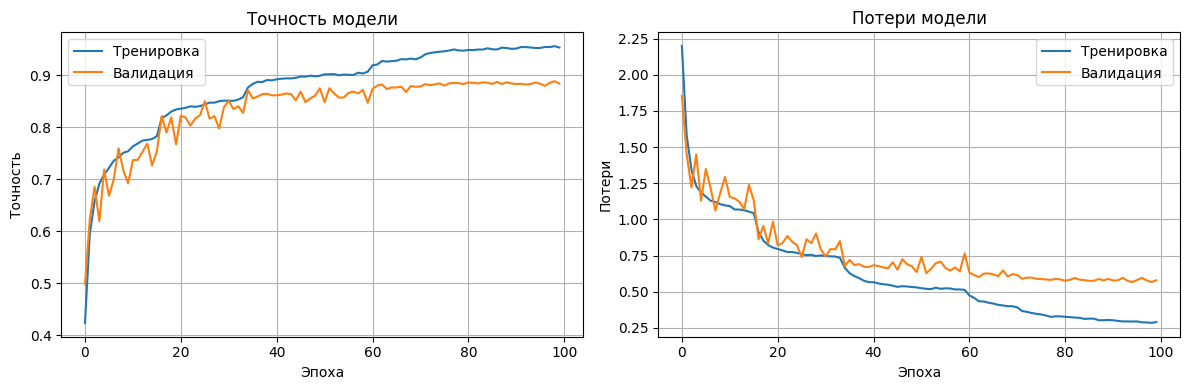

In [11]:
print("\n=== Блок 9: Визуализация результатов ===")

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График точности
ax1.plot(history.history['accuracy'], label='Тренировка')
ax1.plot(history.history['val_accuracy'], label='Валидация')
ax1.set_title('Точность модели')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.legend()
ax1.grid(True)

# График потерь
ax2.plot(history.history['loss'], label='Тренировка')
ax2.plot(history.history['val_loss'], label='Валидация')
ax2.set_title('Потери модели')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
print("\n=== Блок 10: Сохранение модели ===")
model.save('cifar10_cnn_model.h5')
print("Модель сохранена как 'cifar10_cnn_model.h5'")


=== Блок 10: Сохранение модели ===
Модель сохранена как 'cifar10_cnn_model.h5'
